<a href="https://www.kaggle.com/code/rabiabatool021/rabia-batool-vgg16-transfer-learning?scriptVersionId=333748784" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

Image Classification with Transfer Learning — VGG16

**Dataset:** CIFAR-10 (built-in via `tensorflow.keras.datasets`)

# Overview
This notebook demonstrates Transfer Learning using the VGG16 architecture pretrained on ImageNet. We fine-tune it on the CIFAR-10 dataset, which contains 60,000 color images across 10 classes: `airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck`.

 Transfer Learning Strategy
 1. Load VGG16 pretrained on ImageNet (without the top classification head)
 2. Freeze all convolutional base layers initially
 3. Add a custom classification head on top
 4. Train only the new head (**Feature Extraction** — Phase 1)
 5. Unfreeze the last few layers and fine-tune end-to-end (**Fine-Tuning**— Phase 2)


# Step 1: Install & Import Libraries 
****
If running in Colab / a fresh environment, uncomment the line below
#pip install -q tensorflow matplotlib scikit-learn seaborn

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
 
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix
 
print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))
 
# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


#  Step 2: Load & Explore the CIFAR-10 Dataset****

CIFAR-10 has 60,000 32x32 color images across 10 classes (50,000 train / 10,000 test).
 
#  Load Dataset

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4443s 26us/step
Training Images : (50000, 32, 32, 3)
Training Labels : (50000, 1)
Test Images     : (10000, 32, 32, 3)
Test Labels     : (10000, 1)
Train: 45000 | Val: 5000 | Test: 10000


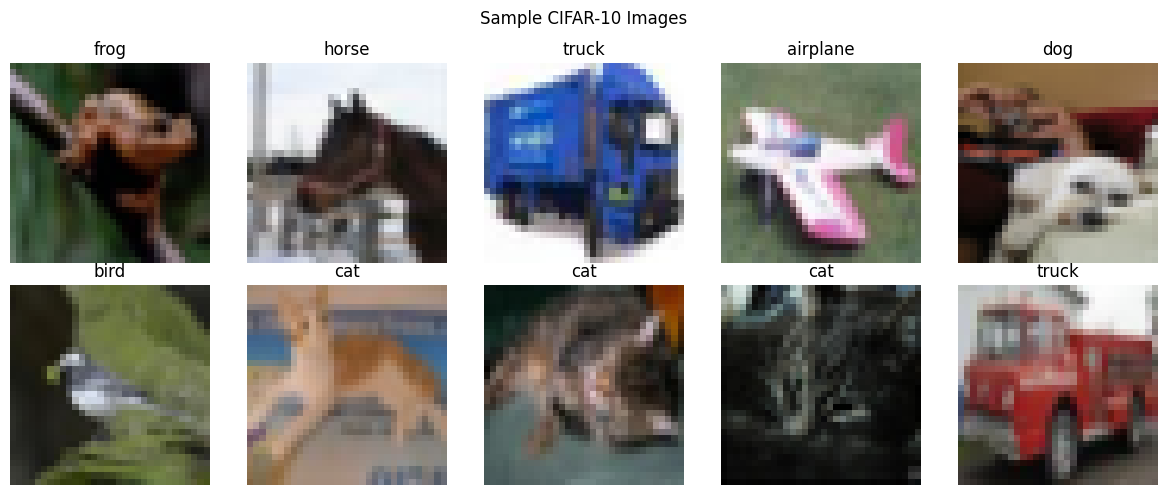

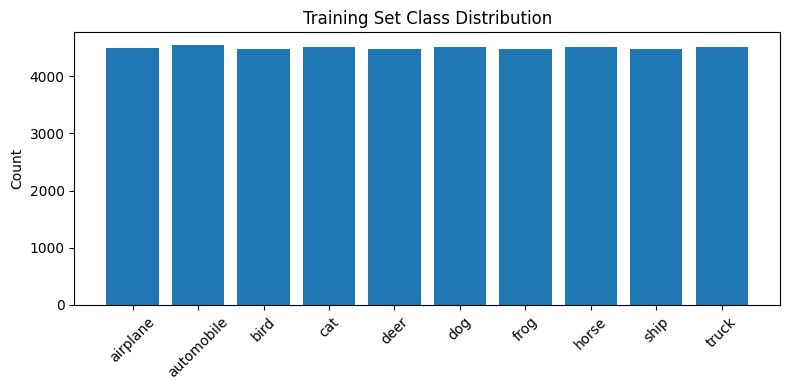

In [3]:
(x_train_full, y_train_full), (x_test, y_test) = cifar10.load_data()
 
CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']
 
print("Training Images :", x_train_full.shape)
print("Training Labels :", y_train_full.shape)
print("Test Images     :", x_test.shape)
print("Test Labels     :", y_test.shape)
 
# Carve out a validation split from the training set
val_split = 0.1
n_val = int(len(x_train_full) * val_split)
 
x_val, y_val = x_train_full[:n_val], y_train_full[:n_val]
x_train, y_train = x_train_full[n_val:], y_train_full[n_val:]
 
print(f"Train: {x_train.shape[0]} | Val: {x_val.shape[0]} | Test: {x_test.shape[0]}")
 
# Flatten label arrays
y_train = y_train.flatten()
y_val = y_val.flatten()
y_test = y_test.flatten()
 
# Quick visual sanity check
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i])
    ax.set_title(CLASS_NAMES[y_train[i]])
    ax.axis('off')
plt.suptitle("Sample CIFAR-10 Images")
plt.tight_layout()
plt.show()
 
# Class distribution check
unique, counts = np.unique(y_train, return_counts=True)
plt.figure(figsize=(8, 4))
plt.bar([CLASS_NAMES[i] for i in unique], counts)
plt.title("Training Set Class Distribution")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


#  Step 3: Preprocessing & Data Augmentation****

VGG16 expects images sized at least 32x32 (we'll upscale to 48x48 for better feature resolution) and preprocessed with `vgg16.preprocess_input` (BGR conversion + ImageNet mean subtraction, no /255 scaling).

In [4]:
IMG_SIZE = 48        # Upscaled from 32x32 for richer VGG16 feature maps
BATCH_SIZE = 64
NUM_CLASSES = 10
 
def build_dataset(images, labels, training=False, batch_size=BATCH_SIZE):
    labels_oh = tf.one_hot(labels, NUM_CLASSES)
    ds = tf.data.Dataset.from_tensor_slices((images, labels_oh))
 
    def _resize_preprocess(img, label):
        img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
        img = preprocess_input(img)  # VGG16-specific preprocessing
        return img, label
 
    if training:
        ds = ds.shuffle(10000, seed=SEED)
 
    ds = ds.map(_resize_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
 
    if training:
        # Lightweight augmentation layer applied after resizing
        augment = keras.Sequential([
            layers.RandomFlip("horizontal"),
            layers.RandomRotation(0.05),
            layers.RandomZoom(0.1),
            layers.RandomTranslation(0.05, 0.05),
        ])
        ds = ds.map(lambda x, y: (augment(x, training=True), y),
                    num_parallel_calls=tf.data.AUTOTUNE)
 
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds
 
train_ds = build_dataset(x_train, y_train, training=True)
val_ds = build_dataset(x_val, y_val, training=False)
test_ds = build_dataset(x_test, y_test, training=False)
 
print("Datasets ready. Example batch shape:")
for imgs, lbls in train_ds.take(1):
    print(imgs.shape, lbls.shape)

I0000 00:00:1783578170.689535      22 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Datasets ready. Example batch shape:
(64, 48, 48, 3) (64, 10)


# Step 4: Build the VGG16 Transfer Learning Model****

Load VGG16 pretrained on ImageNet without its top classification layers, then attach a custom classification head.


In [5]:
def build_model(img_size=IMG_SIZE, num_classes=NUM_CLASSES):
    base_model = VGG16(
        weights='imagenet',
        include_top=False,
        input_shape=(img_size, img_size, 3)
    )
    base_model.trainable = False  # Freeze for Phase 1 (feature extraction)

    inputs = keras.Input(shape=(img_size, img_size, 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs, name="VGG16_CIFAR10")
    return model, base_model

model, base_model = build_model()
model.summary()

print(f"\nTotal layers in VGG16 base: {len(base_model.layers)}")
for i, layer in enumerate(base_model.layers):
    print(i, layer.name, layer.__class__.__name__)


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "VGG16_CIFAR10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 1, 1, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,881,226 (56.77 MB)

 Trainable params: 166,026 (648.54 KB)

 Non-trainable params: 14,715,200 (56.13 MB)


Total layers in VGG16 base: 19
0 input_layer_1 InputLayer
1 block1_conv1 Conv2D
2 block1_conv2 Conv2D
3 block1_pool MaxPooling2D
4 block2_conv1 Conv2D
5 block2_conv2 Conv2D
6 block2_pool MaxPooling2D
7 block3_conv1 Conv2D
8 block3_conv2 Conv2D
9 block3_conv3 Conv2D
10 block3_pool MaxPooling2D
11 block4_conv1 Conv2D
12 block4_conv2 Conv2D
13 block4_conv3 Conv2D
14 block4_pool MaxPooling2D
15 block5_conv1 Conv2D
16 block5_conv2 Conv2D
17 block5_conv3 Conv2D
18 block5_pool MaxPooling2D


 # Step 5: Phase 1 — Feature Extraction Training****

Train only the custom head while the VGG16 base is frozen.

In [6]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

EPOCHS_PHASE1 = 15

callbacks_phase1 = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)
]

history_phase1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_PHASE1,
    callbacks=callbacks_phase1
)

print("\nPhase 1 complete.")
print(f"Best val_accuracy: {max(history_phase1.history['val_accuracy']):.4f}")



Epoch 1/15
  6/704 ━━━━━━━━━━━━━━━━━━━━ 21s 31ms/step - accuracy: 0.1299 - loss: 3.4388

I0000 00:00:1783578188.399291      68 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


704/704 ━━━━━━━━━━━━━━━━━━━━ 51s 64ms/step - accuracy: 0.4946 - loss: 1.5036 - val_accuracy: 0.6712 - val_loss: 0.9482 - learning_rate: 0.0010
Epoch 2/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 57ms/step - accuracy: 0.5878 - loss: 1.1775 - val_accuracy: 0.6864 - val_loss: 0.8950 - learning_rate: 0.0010
Epoch 3/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 58ms/step - accuracy: 0.6097 - loss: 1.1149 - val_accuracy: 0.6914 - val_loss: 0.8817 - learning_rate: 0.0010
Epoch 4/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 57ms/step - accuracy: 0.6218 - loss: 1.0817 - val_accuracy: 0.6972 - val_loss: 0.8603 - learning_rate: 0.0010
Epoch 5/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 57ms/step - accuracy: 0.6317 - loss: 1.0573 - val_accuracy: 0.6948 - val_loss: 0.8641 - learning_rate: 0.0010
Epoch 6/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 57ms/step - accuracy: 0.6356 - loss: 1.0415 - val_accuracy: 0.7062 - val_loss: 0.8524 - learning_rate: 0.0010
Epoch 7/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 57ms/step - accuracy: 0.6400 - loss: 1.0320


#  Step 6: Phase 2 — Fine-Tuning****

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Training Images : (50000, 32, 32, 3)
Training Labels : (50000, 1)
Test Images     : (10000, 32, 32, 3)
Test Labels     : (10000, 1)
Train: 45000 | Val: 5000 | Test: 10000


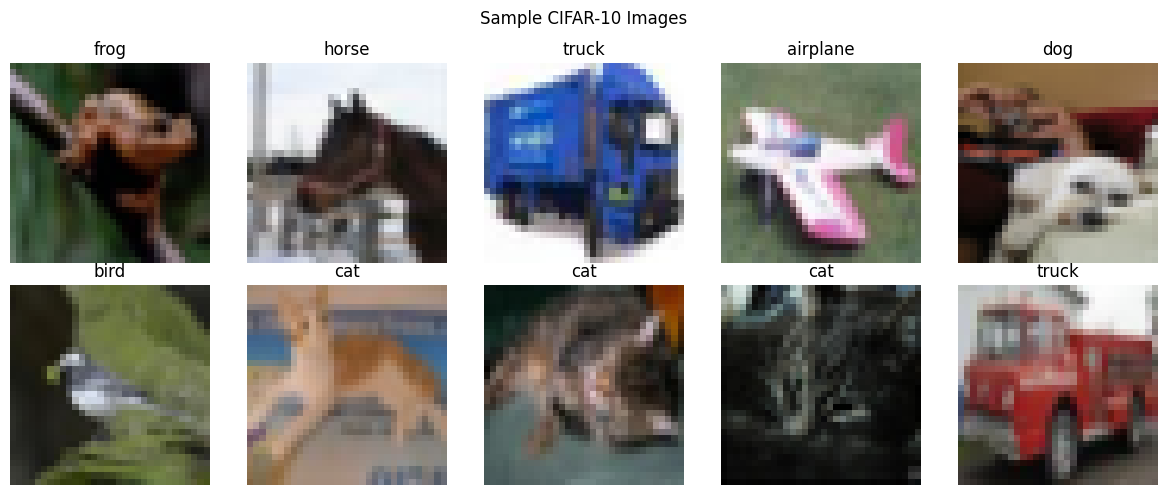

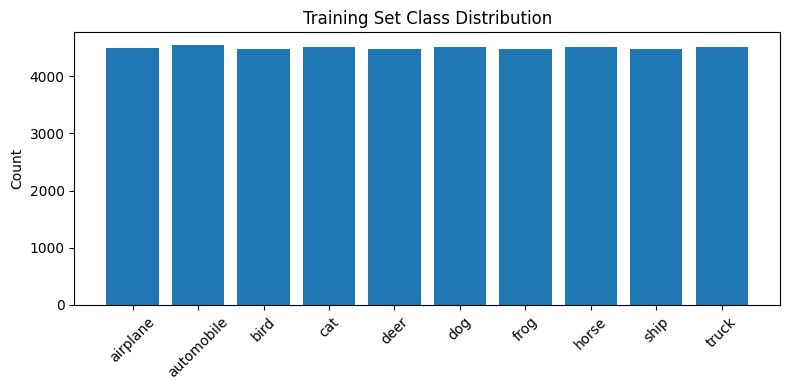

Datasets ready. Example batch shape:
(64, 48, 48, 3) (64, 10)


In [7]:
# # Image Classification with Transfer Learning — VGG16
#
# **Dataset:** CIFAR-10 (built-in via `tensorflow.keras.datasets`)
#
# ## 📌 Overview
# This notebook demonstrates **Transfer Learning** using the VGG16 architecture pretrained on ImageNet. We fine-tune it on the CIFAR-10 dataset, which contains 60,000 color images across 10 classes: `airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck`.
#
# ## 🔄 Transfer Learning Strategy
# 1. Load VGG16 pretrained on ImageNet (without the top classification head)
# 2. Freeze all convolutional base layers initially
# 3. Add a custom classification head on top
# 4. Train only the new head (**Feature Extraction** — Phase 1)
# 5. Unfreeze the last few layers and fine-tune end-to-end (**Fine-Tuning** — Phase 2)
#

# ## Step 1: Install & Import Libraries

# If running in Colab / a fresh environment, uncomment the line below
# !pip install -q tensorflow matplotlib scikit-learn seaborn

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)


# ## Step 2: Load & Explore the CIFAR-10 Dataset
#
# CIFAR-10 has 60,000 32x32 color images across 10 classes (50,000 train / 10,000 test).

# Load Dataset
(x_train_full, y_train_full), (x_test, y_test) = cifar10.load_data()

CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print("Training Images :", x_train_full.shape)
print("Training Labels :", y_train_full.shape)
print("Test Images     :", x_test.shape)
print("Test Labels     :", y_test.shape)

# Carve out a validation split from the training set
val_split = 0.1
n_val = int(len(x_train_full) * val_split)

x_val, y_val = x_train_full[:n_val], y_train_full[:n_val]
x_train, y_train = x_train_full[n_val:], y_train_full[n_val:]

print(f"Train: {x_train.shape[0]} | Val: {x_val.shape[0]} | Test: {x_test.shape[0]}")

# Flatten label arrays
y_train = y_train.flatten()
y_val = y_val.flatten()
y_test = y_test.flatten()

# Quick visual sanity check
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i])
    ax.set_title(CLASS_NAMES[y_train[i]])
    ax.axis('off')
plt.suptitle("Sample CIFAR-10 Images")
plt.tight_layout()
plt.show()

# Class distribution check
unique, counts = np.unique(y_train, return_counts=True)
plt.figure(figsize=(8, 4))
plt.bar([CLASS_NAMES[i] for i in unique], counts)
plt.title("Training Set Class Distribution")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# ## Step 3: Preprocessing & Data Augmentation
#
# VGG16 expects images sized at least 32x32 (we'll upscale to 48x48 for better feature resolution) and preprocessed with `vgg16.preprocess_input` (BGR conversion + ImageNet mean subtraction, no /255 scaling).

IMG_SIZE = 48        # Upscaled from 32x32 for richer VGG16 feature maps
BATCH_SIZE = 64
NUM_CLASSES = 10

def build_dataset(images, labels, training=False, batch_size=BATCH_SIZE):
    labels_oh = tf.one_hot(labels, NUM_CLASSES)
    ds = tf.data.Dataset.from_tensor_slices((images, labels_oh))

    def _resize_preprocess(img, label):
        img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
        img = preprocess_input(img)  # VGG16-specific preprocessing
        return img, label

    if training:
        ds = ds.shuffle(10000, seed=SEED)

    ds = ds.map(_resize_preprocess, num_parallel_calls=tf.data.AUTOTUNE)

    if training:
        # Lightweight augmentation layer applied after resizing
        augment = keras.Sequential([
            layers.RandomFlip("horizontal"),
            layers.RandomRotation(0.05),
            layers.RandomZoom(0.1),
            layers.RandomTranslation(0.05, 0.05),
        ])
        ds = ds.map(lambda x, y: (augment(x, training=True), y),
                    num_parallel_calls=tf.data.AUTOTUNE)

    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = build_dataset(x_train, y_train, training=True)
val_ds = build_dataset(x_val, y_val, training=False)
test_ds = build_dataset(x_test, y_test, training=False)

print("Datasets ready. Example batch shape:")
for imgs, lbls in train_ds.take(1):
    print(imgs.shape, lbls.shape)













 Unfreeze the last convolutional block of VGG16 (`block5`) and retrain end-to-end with a very low learning rate so pretrained weights shift gently instead of being overwritten.

In [8]:
# Unfreeze only block5 (last conv block) of VGG16
base_model.trainable = True
fine_tune_at = None
for i, layer in enumerate(base_model.layers):
    if layer.name == 'block5_conv1':
        fine_tune_at = i
        break

if fine_tune_at is None:
    raise ValueError("Layer 'block5_conv1' not found in base_model.layers")

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False
for layer in base_model.layers[fine_tune_at:]:
    layer.trainable = True

trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f"Unfrozen from layer index {fine_tune_at} ({base_model.layers[fine_tune_at].name})")
print(f"Trainable base layers: {trainable_count} / {len(base_model.layers)}")

# Recompile with a much lower LR — critical to avoid destroying pretrained features
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

EPOCHS_PHASE2 = 15

callbacks_phase2 = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7)
]

history_phase2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_PHASE2,
    callbacks=callbacks_phase2
)

print("\nPhase 2 (fine-tuning) complete.")
print(f"Best val_accuracy: {max(history_phase2.history['val_accuracy']):.4f}")

Unfrozen from layer index 15 (block5_conv1)
Trainable base layers: 4 / 19
Epoch 1/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 53s 67ms/step - accuracy: 0.7169 - loss: 0.8204 - val_accuracy: 0.7940 - val_loss: 0.6088 - learning_rate: 1.0000e-05
Epoch 2/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 45s 63ms/step - accuracy: 0.7549 - loss: 0.7084 - val_accuracy: 0.8068 - val_loss: 0.5571 - learning_rate: 1.0000e-05
Epoch 3/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 44s 62ms/step - accuracy: 0.7767 - loss: 0.6511 - val_accuracy: 0.8088 - val_loss: 0.5451 - learning_rate: 1.0000e-05
Epoch 4/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 43s 61ms/step - accuracy: 0.7938 - loss: 0.6008 - val_accuracy: 0.8262 - val_loss: 0.5015 - learning_rate: 1.0000e-05
Epoch 5/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 43s 62ms/step - accuracy: 0.8041 - loss: 0.5710 - val_accuracy: 0.8332 - val_loss: 0.4892 - learning_rate: 1.0000e-05
Epoch 6/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 43s 61ms/step - accuracy: 0.8176 - loss: 0.5333 - val_accuracy: 0.8274 - val_loss: 0.4837 - lear

#   Step 7: Training Curves Visualization**# 


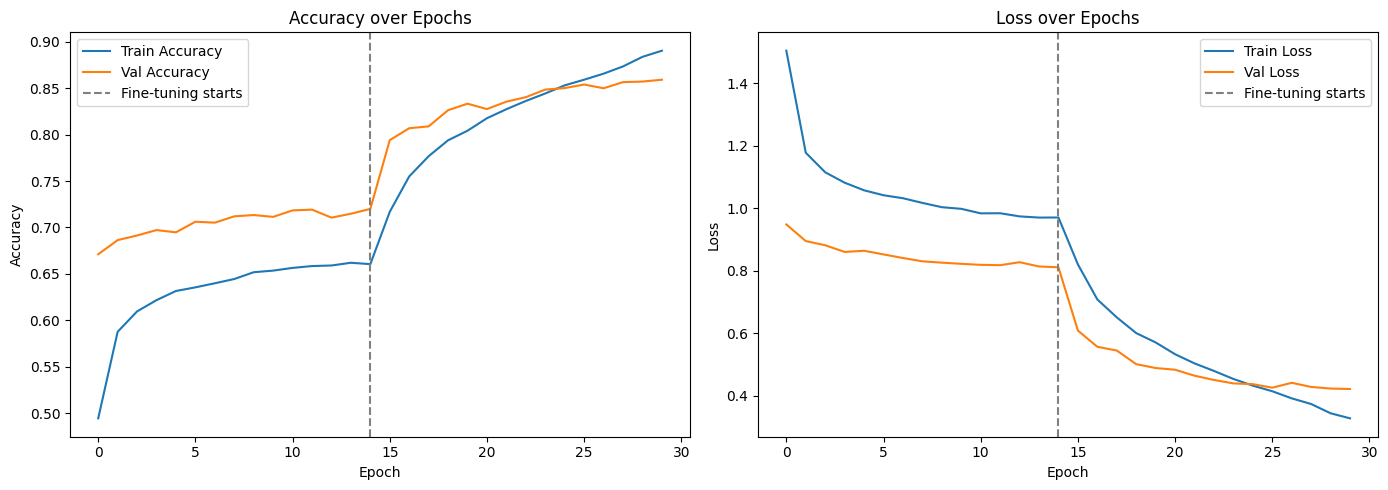

In [9]:
def combine_histories(h1, h2):
    combined = {}
    for key in h1.history:
        combined[key] = h1.history[key] + h2.history[key]
    return combined

history = combine_histories(history_phase1, history_phase2)
phase1_epochs = len(history_phase1.history['loss'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['accuracy'], label='Train Accuracy')
axes[0].plot(history['val_accuracy'], label='Val Accuracy')
axes[0].axvline(x=phase1_epochs - 1, color='gray', linestyle='--', label='Fine-tuning starts')
axes[0].set_title('Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history['loss'], label='Train Loss')
axes[1].plot(history['val_loss'], label='Val Loss')
axes[1].axvline(x=phase1_epochs - 1, color='gray', linestyle='--', label='Fine-tuning starts')
axes[1].set_title('Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()


# Step 8: Evaluation on Test Set****



157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.8481 - loss: 0.4618

Test Loss: 0.4618
Test Accuracy: 0.8481
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step

Classification Report:
              precision    recall  f1-score   support

    airplane       0.87      0.88      0.88      1000
  automobile       0.89      0.93      0.91      1000
        bird       0.85      0.80      0.82      1000
         cat       0.78      0.65      0.71      1000
        deer       0.84      0.80      0.82      1000
         dog       0.76      0.81      0.78      1000
        frog       0.80      0.92      0.85      1000
       horse       0.87      0.87      0.87      1000
        ship       0.92      0.92      0.92      1000
       truck       0.91      0.89      0.90      1000

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



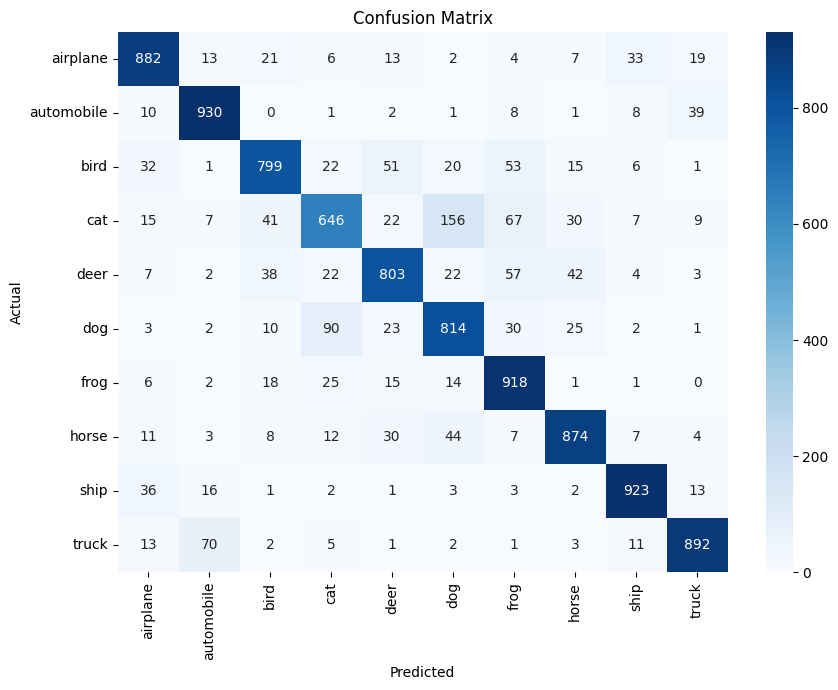

In [10]:
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Gather predictions for detailed metrics
y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()


# ** Step 9: Visualize Predictions**

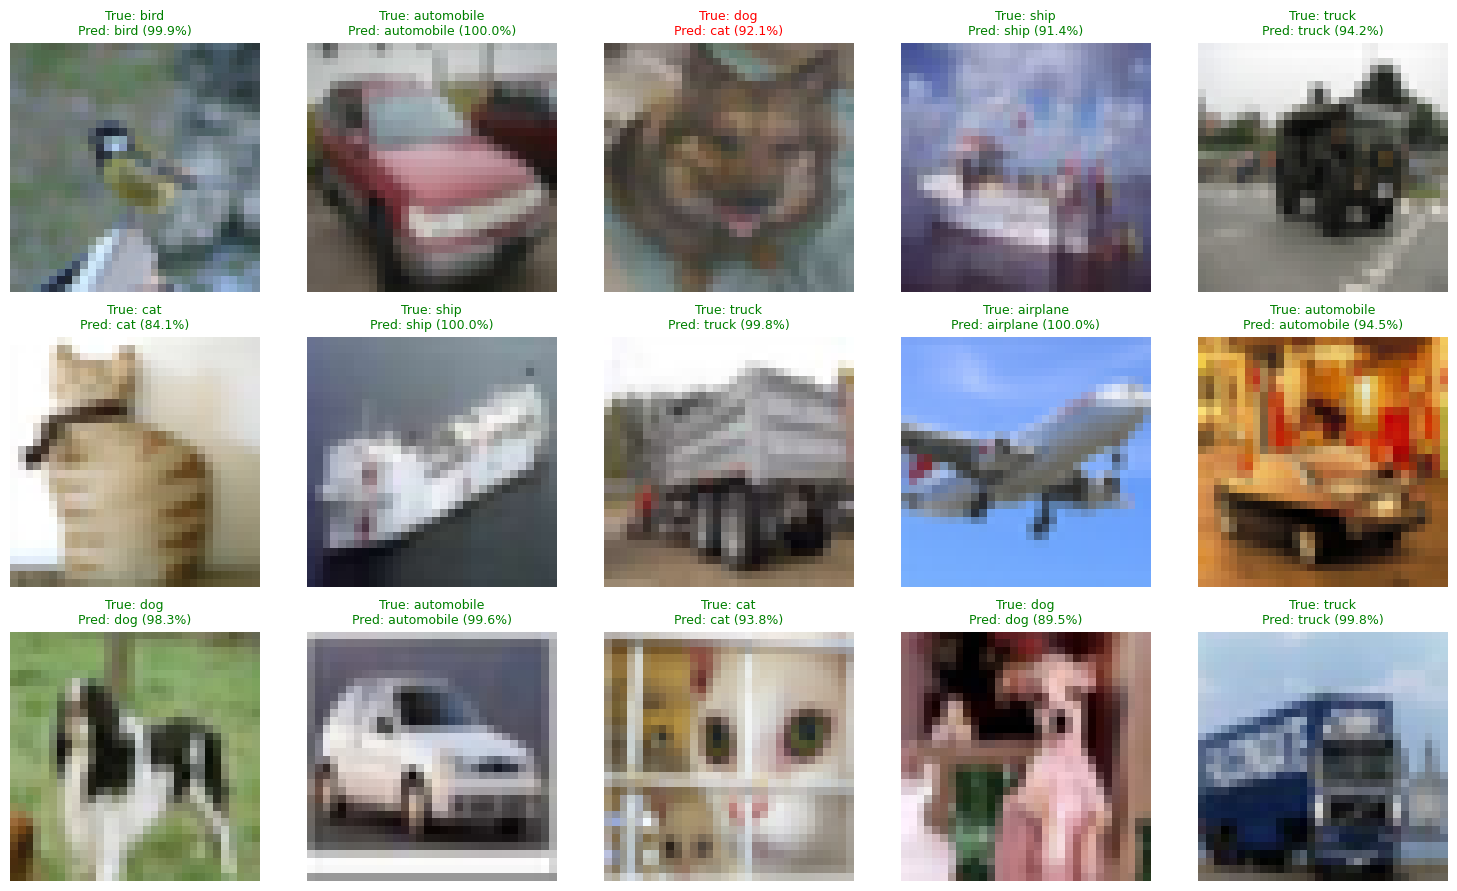

In [11]:
def show_predictions(images, true_labels, pred_labels, pred_probs, n=15):
    idx = np.random.choice(len(images), n, replace=False)
    plt.figure(figsize=(15, 9))
    for i, index in enumerate(idx):
        plt.subplot(3, 5, i + 1)
        plt.imshow(images[index])
        true_name = CLASS_NAMES[true_labels[index]]
        pred_name = CLASS_NAMES[pred_labels[index]]
        confidence = pred_probs[index][pred_labels[index]] * 100
        color = 'green' if true_name == pred_name else 'red'
        plt.title(f"True: {true_name}\nPred: {pred_name} ({confidence:.1f}%)",
                   color=color, fontsize=9)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

show_predictions(x_test, y_test, y_pred, y_pred_probs, n=15)


# ** Step 10: Per-Class Accuracy Analysis******

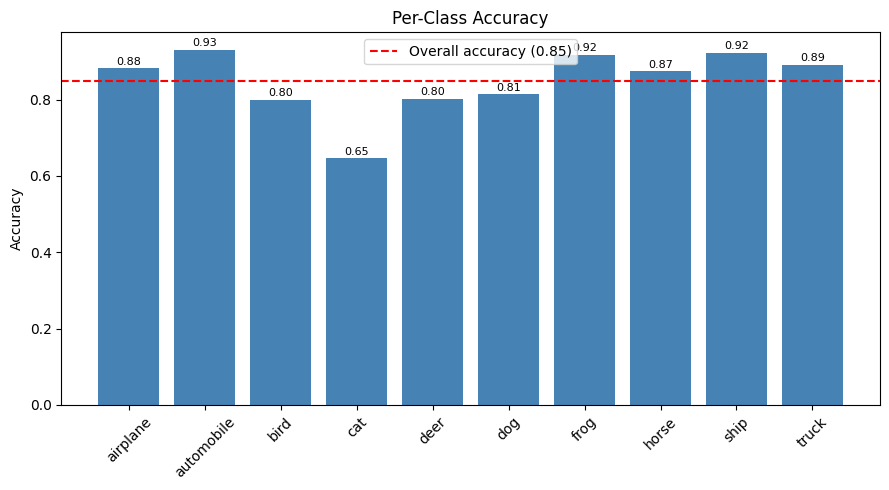

Top confused pairs (excluding diagonal):
cat -> predicted as dog: 156 times
truck -> predicted as automobile: 70 times
cat -> predicted as frog: 67 times
deer -> predicted as frog: 57 times
bird -> predicted as frog: 53 times


In [12]:
per_class_acc = cm.diagonal() / cm.sum(axis=1)
plt.figure(figsize=(9, 5))
bars = plt.bar(CLASS_NAMES, per_class_acc, color='steelblue')
plt.axhline(y=test_accuracy, color='red', linestyle='--',
            label=f'Overall accuracy ({test_accuracy:.2f})')
plt.title('Per-Class Accuracy')
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
plt.legend()
for bar, acc in zip(bars, per_class_acc):
    plt.text(bar.get_x() + bar.get_width() / 2, acc + 0.01, f"{acc:.2f}",
              ha='center', fontsize=8)
plt.tight_layout()
plt.show()

print("Top confused pairs (excluding diagonal):")
cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)
flat_indices = np.dstack(
    np.unravel_index(np.argsort(cm_no_diag.ravel())[::-1], cm_no_diag.shape)
)[0]

seen = set()
count = 0
for i, j in flat_indices:
    if cm_no_diag[i, j] == 0 or count >= 5:
        break
    pair = tuple(sorted((i, j)))
    if pair in seen:
        continue
    seen.add(pair)
    print(f"{CLASS_NAMES[i]} -> predicted as {CLASS_NAMES[j]}: {cm_no_diag[i, j]} times")
    count += 1

Summary

 This notebook implemented a **two-phase transfer learning pipeline** using VGG16 pretrained on ImageNet, adapted to the 10-class CIFAR-10 dataset
 
 1. **Data pipeline**: loaded CIFAR-10, split into train/val/test, resized 32x32 -> 48x48, applied VGG16-specific preprocessing, and added on-the-fly augmentation (flip, rotation, zoom, translation) for the training set.
2. **Model architecture**: VGG16 convolutional base (no top) + GlobalAveragePooling2D + Dense(256) + BatchNorm + Dropout + Dense(128) + Dropout + Dense(10, softmax).
3. **Phase 1 (feature extraction)**: froze the entire VGG16 base and trained only the custom head with a standard learning rate (1e-3). 4. **Phase 2 (fine-tuning)**: unfroze `block5` (the last convolutional block) and retrained end-to-end with a very low learning rate (1e-5) to gently adapt high-level features without destroying pretrained weights.
 5. **Evaluation**: combined training curves across both phases, test-set accuracy/loss, classification report, confusion matrix, sample prediction visualization, and per-class accuracy breakdown with the most-confused class pairs.

 Key Takeaways
 - VGG16 learns hierarchical features (edges -> textures -> objects) from ImageNet.
- Frozen base layers in Phase 1 prevent catastrophic forgetting of pretrained knowledge.
 - Fine-tuning with a tiny learning rate in Phase 2 adapts high-level features to the CIFAR-10 distribution without wrecking earlier layers.
 - Common confusions tend to appear between visually similar classes: cat <-> dog, automobile <-> truck, bird <-> airplane.
 - GlobalAveragePooling + Dropout helps control overfitting on a comparatively small dataset relative to VGG16's capacity.


# Step 11: Save Model

In [13]:
model.save("/kaggle/working/vgg16_transfer_learning_cifar10.keras")

In [14]:
import os
print(os.listdir('/kaggle/working/'))

['vgg16_transfer_learning_cifar10.keras', '__notebook__.ipynb']


In [15]:
model.save("vgg16_cifar10.keras")